In [32]:
import copy
import os
import random
import re
from dataclasses import dataclass
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 5)

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DATA_PATH = r"D:\Innomatics\NLP\IMDB Dataset.csv\IMDB Dataset.csv"
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 2
EARLY_STOPPING_PATIENCE = 2
MAX_SAMPLES = None  # Set a number like 10000 if you want faster experimentation.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Dataset path exists: {os.path.exists(DATA_PATH)}")

Using device: cuda
Dataset path exists: True


# 1. Data Loading and Preprocessing

In [3]:
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)

df = df.dropna(subset=["review", "sentiment"]).copy()
df["review"] = df["review"].apply(clean_text)
df = df[df["review"].str.len() > 0].copy()
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

if MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df = df.groupby("label", group_keys=False).apply(
        lambda x: x.sample(MAX_SAMPLES // 2, random_state=42)
    ).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df[["review", "sentiment", "label"]].head())
print("\nClass distribution:")
print(df["sentiment"].value_counts())

Original shape: (50000, 2)
Cleaned shape: (50000, 3)
                                              review sentiment  label
0  One of the other reviewers has mentioned that ...  positive      1
1  A wonderful little production. The filming tec...  positive      1
2  I thought this was a wonderful way to spend ti...  positive      1
3  Basically there's a family where a little boy ...  negative      0
4  Petter Mattei's "Love in the Time of Money" is...  positive      1

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [21]:
print("Missing values before cleaning:")
raw_df = pd.read_csv(DATA_PATH)
print(raw_df.isnull().sum())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

duplicate_count = df.duplicated(subset=["review"]).sum()
print(f"\nDuplicate reviews: {duplicate_count}")

df["review_length_words"] = df["review"].apply(lambda x: len(str(x).split()))
print("\nReview length statistics:")
print(df["review_length_words"].describe())


Missing values before cleaning:
review       0
sentiment    0
dtype: int64

Missing values after cleaning:
review       0
sentiment    0
label        0
dtype: int64

Duplicate reviews: 422

Review length statistics:
count    50000.000000
mean       228.865940
std        169.589105
min          4.000000
25%        125.000000
50%        171.000000
75%        278.000000
max       2459.000000
Name: review_length_words, dtype: float64


C:\Users\Vidhi\AppData\Local\Temp\ipykernel_38764\4211478990.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", palette="Set2")


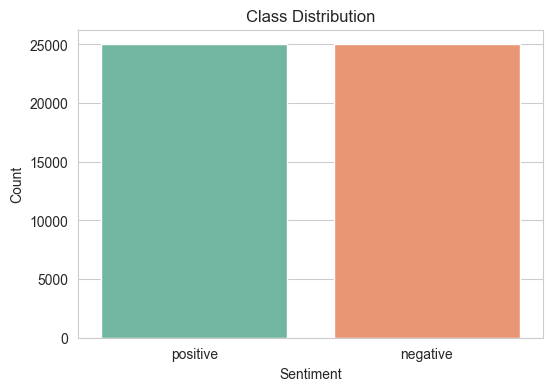

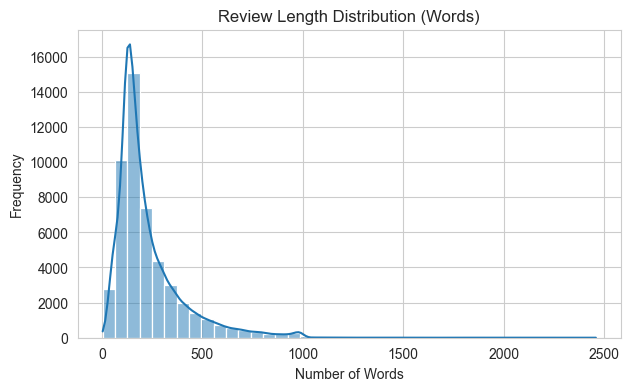

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", palette="Set2")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df["review_length_words"], bins=40, kde=True)
plt.title("Review Length Distribution (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [29]:
print("Sample positive review:\n")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

print("\n" + "="*100 + "\n")

print("Sample negative review:\n")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])

Sample positive review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. I would say the main appeal of the show is due to the fact that i

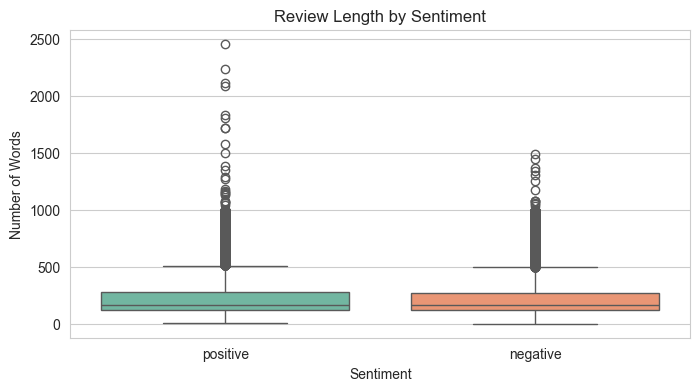

In [30]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="sentiment", y="review_length_words", hue="sentiment", palette="Set2", legend=False)
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()

In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 35000
Validation size: 7500
Test size: 7500


In [23]:
def show_label_distribution(name, data):
    distribution = data["sentiment"].value_counts(normalize=True) * 100
    print(f"{name} label distribution (%):")
    print(distribution.round(2))
    print()

show_label_distribution("Train", train_df)
show_label_distribution("Validation", val_df)
show_label_distribution("Test", test_df)


Train label distribution (%):
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

Validation label distribution (%):
sentiment
negative    50.0
positive    50.0
Name: proportion, dtype: float64

Test label distribution (%):
sentiment
negative    50.0
positive    50.0
Name: proportion, dtype: float64



# 2. Tokenization

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [6]:
class IMDbDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [7]:
train_dataset = IMDbDataset(train_df["review"], train_df["label"], tokenizer, MAX_LENGTH)
val_dataset = IMDbDataset(val_df["review"], val_df["label"], tokenizer, MAX_LENGTH)
test_dataset = IMDbDataset(test_df["review"], test_df["label"], tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items()})

{'input_ids': (16, 256), 'token_type_ids': (16, 256), 'attention_mask': (16, 256), 'labels': (16,)}


# 3. Model Utilities

In [26]:
@dataclass
class ExperimentResult:
    name: str
    history: pd.DataFrame
    metrics: dict
    confusion_matrix: np.ndarray


def get_backbone(model):
    if hasattr(model, "bert"):
        return model.bert
    if hasattr(model, "base_model"):
        return model.base_model
    raise AttributeError("Could not find transformer backbone in the model.")


def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
    return model.to(device)


def freeze_entire_backbone(model):
    backbone = get_backbone(model)
    for param in backbone.parameters():
        param.requires_grad = False


def unfreeze_last_n_bert_layers(model, n_layers=2):
    backbone = get_backbone(model)
    for param in backbone.parameters():
        param.requires_grad = False

    if hasattr(backbone, "encoder") and hasattr(backbone.encoder, "layer"):
        for layer in backbone.encoder.layer[-n_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    if hasattr(backbone, "pooler") and backbone.pooler is not None:
        for param in backbone.pooler.parameters():
            param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True


def compute_classification_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }
    return metrics


def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

# 4. Training and Evaluation Functions

In [28]:
def train_one_epoch(model, data_loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(data_loader, desc="Training", leave=False)
    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(data_loader)


@torch.no_grad()
def evaluate_model(model, data_loader):
    model.eval()
    total_loss = 0.0
    predictions = []
    true_labels = []

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

    metrics = compute_classification_metrics(true_labels, predictions)
    metrics["loss"] = total_loss / len(data_loader)
    cm = confusion_matrix(true_labels, predictions)
    return metrics, cm, np.array(true_labels), np.array(predictions)


def run_experiment(experiment_name, freeze_strategy):
    print(f"\n{'=' * 80}")
    print(f"Running experiment: {experiment_name}")
    print(f"{'=' * 80}")

    model = build_model()
    freeze_strategy(model)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LEARNING_RATE
    )

    total_training_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_training_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps
    )

    best_val_f1 = -1
    best_model_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_metrics, _, _, _ = evaluate_model(model, val_loader)

        epoch_result = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1_score"]
        }
        history.append(epoch_result)
        print(epoch_result)

        if val_metrics["f1_score"] > best_val_f1:
            best_val_f1 = val_metrics["f1_score"]
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("Early stopping triggered.")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    test_metrics, cm, y_true, y_pred = evaluate_model(model, test_loader)
    print("\nTest Metrics:")
    for key, value in test_metrics.items():
        print(f"{key}: {value:.4f}")

    return ExperimentResult(
        name=experiment_name,
        history=pd.DataFrame(history),
        metrics=test_metrics,
        confusion_matrix=cm)

# 5. Experiment 1: Freeze BERT Layers and Train only the Classifier

In [10]:
experiment_1 = run_experiment(
    experiment_name="Experiment 1 - Frozen BERT Backbone",
    freeze_strategy=freeze_entire_backbone
)

experiment_1.history


Running experiment: Experiment 1 - Frozen BERT Backbone


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 1,538 / 109,483,778

Epoch 1/2


Training:   0%|          | 0/2188 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.6607894186727308, 'val_loss': 0.651667136500385, 'val_accuracy': 0.6685333333333333, 'val_precision': 0.6271118262268705, 'val_recall': 0.8314666666666667, 'val_f1': 0.7149736299013988}


Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]


Test Metrics:
accuracy: 0.6763
precision: 0.6343
recall: 0.8325
f1_score: 0.7200
loss: 0.6512


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.683643,0.661741,0.648667,0.608653,0.832800,0.703299
1,2,0.660789,0.651667,0.668533,0.627112,0.831467,0.714974


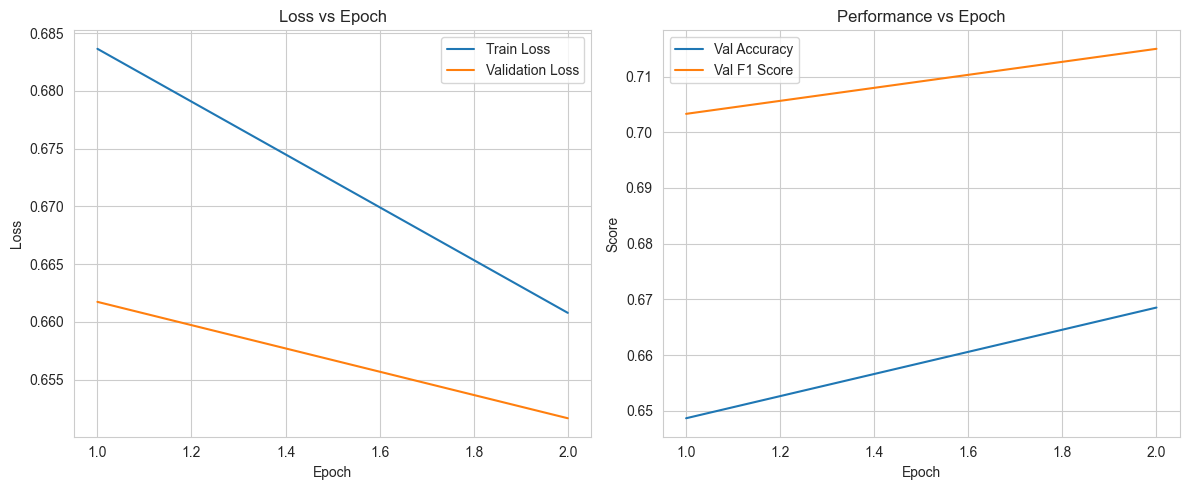

In [18]:
history_df = experiment_1.history

plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

# Accuracy / F1 Plot
plt.subplot(1,2,2)
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.plot(history_df["epoch"], history_df["val_f1"], label="Val F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Performance vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

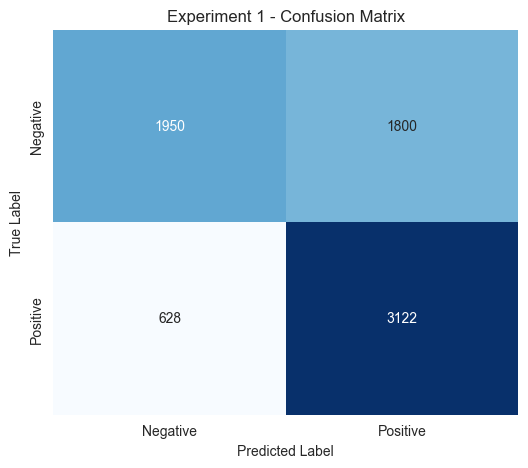

In [12]:
plot_confusion_matrix(
    experiment_1.confusion_matrix,
    title="Experiment 1 - Confusion Matrix")

# 6. Experiment 2: Fine tune the last 2 BERT layers

In [11]:
experiment_2 = run_experiment(
    experiment_name="Experiment 2 - Fine-Tune Last 2 BERT Layers",
    freeze_strategy=lambda model: unfreeze_last_n_bert_layers(model, n_layers=2)
)

experiment_2.history


Running experiment: Experiment 2 - Fine-Tune Last 2 BERT Layers


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 14,767,874 / 109,483,778

Epoch 1/2


Training:   0%|          | 0/2188 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.22876456693211533, 'val_loss': 0.23465225013044438, 'val_accuracy': 0.9089333333333334, 'val_precision': 0.9042973899288163, 'val_recall': 0.9146666666666666, 'val_f1': 0.9094524724910513}


Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]


Test Metrics:
accuracy: 0.9101
precision: 0.9067
recall: 0.9144
f1_score: 0.9105
loss: 0.2270


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.323521,0.244391,0.905467,0.903637,0.907733,0.905680
1,2,0.228765,0.234652,0.908933,0.904297,0.914667,0.909452


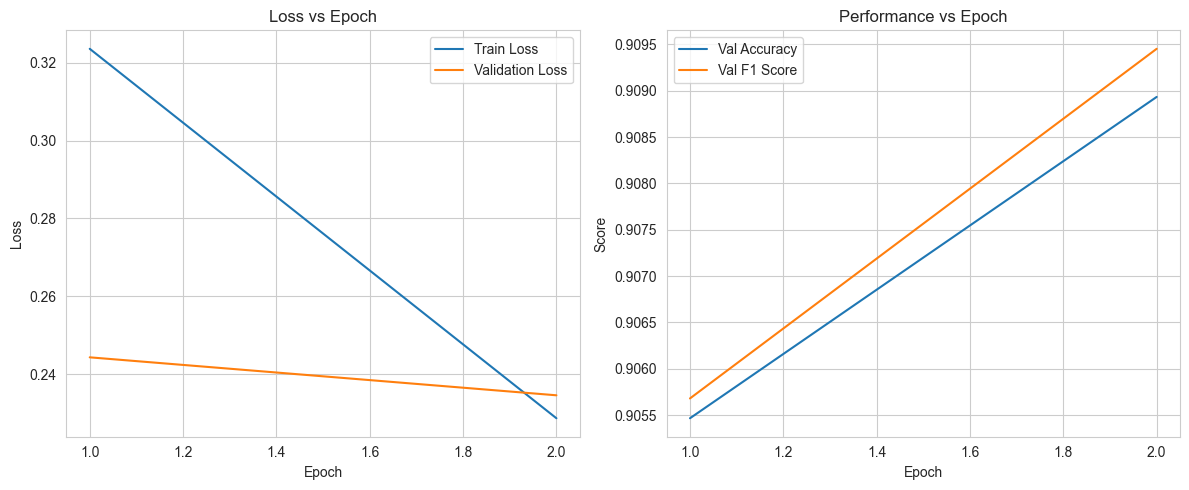

In [19]:
history_df = experiment_2.history

plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

# Accuracy / F1 Plot
plt.subplot(1,2,2)
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.plot(history_df["epoch"], history_df["val_f1"], label="Val F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Performance vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

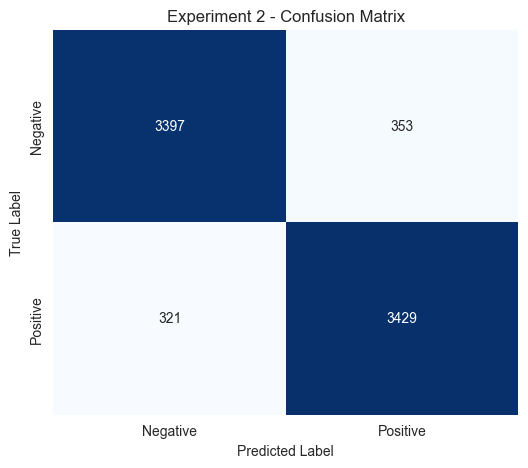

In [13]:
plot_confusion_matrix(
    experiment_2.confusion_matrix,
    title="Experiment 2 - Confusion Matrix")

# 7. Comparision of Experiments

In [14]:
comparison_df = pd.DataFrame([
    {
        "Experiment": experiment_1.name,
        **experiment_1.metrics
    },
    {
        "Experiment": experiment_2.name,
        **experiment_2.metrics
    }
])

comparison_df = comparison_df[[
    "Experiment",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "loss"
]]

comparison_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)

,Experiment,accuracy,precision,recall,f1_score,loss
0,Experiment 2 - Fine-Tune Last 2 BERT Layers,0.910133,0.906663,0.914400,0.910515,0.227009
1,Experiment 1 - Frozen BERT Backbone,0.676267,0.634295,0.832533,0.720018,0.651201


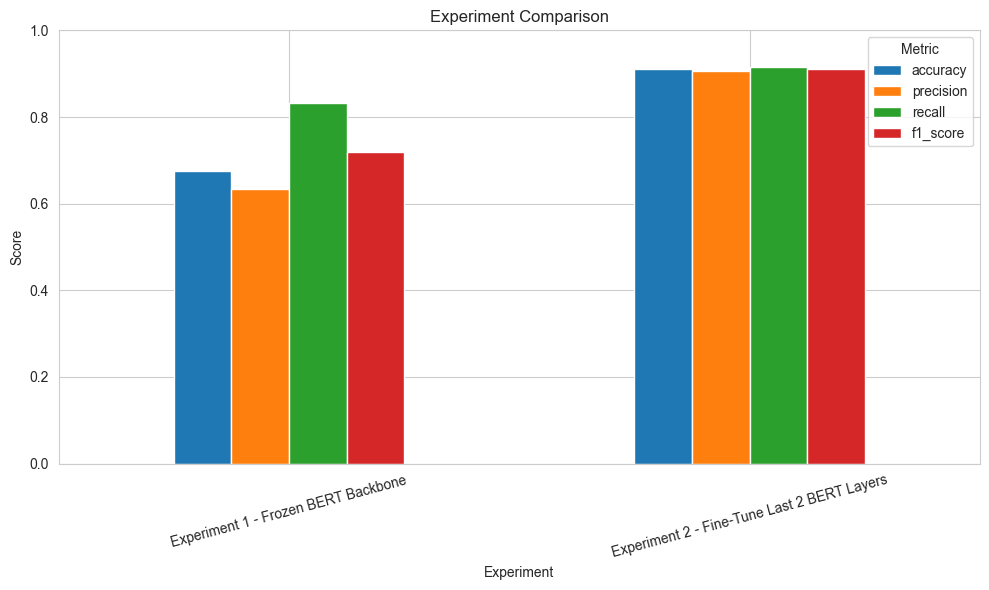

In [15]:
metric_columns = ["accuracy", "precision", "recall", "f1_score"]
plot_df = comparison_df.set_index("Experiment")[metric_columns]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_ylim(0, 1)
ax.set_title("Experiment Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Experiment")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 8. Final Analysis

In [16]:
best_row = comparison_df.sort_values(by="f1_score", ascending=False).iloc[0]

print("Best performing experiment based on F1-score:")
print(best_row)

print("\nAnalysis Summary:")
print("1. Experiment 1 trains only the classifier head while keeping the full BERT backbone frozen.")
print("2. Experiment 2 allows the last two BERT encoder layers to learn task-specific patterns from the IMDB reviews.")
print("3. In most cases, fine-tuning the last two layers should perform better than freezing the full backbone because it adapts the language representations to the sentiment classification task.")
print("4. Accuracy, Precision, Recall, F1-score, and Confusion Matrix together provide a complete evaluation of classification performance.")

Best performing experiment based on F1-score:
Experiment    Experiment 2 - Fine-Tune Last 2 BERT Layers
accuracy                                         0.910133
precision                                        0.906663
recall                                             0.9144
f1_score                                         0.910515
loss                                             0.227009
Name: 1, dtype: object

Analysis Summary:
1. Experiment 1 trains only the classifier head while keeping the full BERT backbone frozen.
2. Experiment 2 allows the last two BERT encoder layers to learn task-specific patterns from the IMDB reviews.
3. In most cases, fine-tuning the last two layers should perform better than freezing the full backbone because it adapts the language representations to the sentiment classification task.
4. Accuracy, Precision, Recall, F1-score, and Confusion Matrix together provide a complete evaluation of classification performance.
